# EDA del histórico procesado — Proyecto EBSA

Este notebook describe y visualiza el histórico que ya fue homologado por `Exploracion_inicial.ipynb`.

Su objetivo es responder: qué datos hay, qué calidad tienen, cómo se distribuyen y qué decisiones deben tomarse antes de la reconstrucción y el modelado.



In [56]:
from pathlib import Path
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from IPython.display import display

sns.set_theme(style="whitegrid")
DATA_DIR = Path(os.environ.get("EBSA_DATOS", r"C:\Users\patri\Documents\Datos_Ebsa"))
#DATA_DIR = Path(os.environ.get("EBSA_DATOS", r"C:\Users\Home\Documents\Datos_Ebsa"))
HIST_DIR = DATA_DIR / "01_historico_procesado"

archivos = sorted(HIST_DIR.glob("historico_*.parquet"))
if not archivos:
    raise FileNotFoundError(f"No se encontraron historico_*.parquet en {HIST_DIR}")
print("Archivos:", [p.name for p in archivos])

Archivos: ['historico_2022.parquet', 'historico_2023.parquet', 'historico_2024.parquet', 'historico_2025.parquet', 'historico_2026.parquet']


## 1. Inventario y cobertura

Primero se verifica el periodo, el número de filas y las columnas disponibles. Esta sección utiliza metadatos Parquet y no carga todos los archivos a la vez.

In [57]:
inventario = []
for ruta in archivos:
    pf = pq.ParquetFile(ruta)
    inventario.append({
        "archivo": ruta.name,
        "filas": pf.metadata.num_rows,
        "columnas": len(pf.schema_arrow.names),
        "tiene_NIU": "NIU" in pf.schema_arrow.names,
        "tiene_periodo": "periodo" in pf.schema_arrow.names,
    })
inventario = pd.DataFrame(inventario)
display(inventario)


,archivo,filas,columnas,tiene_NIU,tiene_periodo
0,historico_2022.parquet,4701934,30,True,True
1,historico_2023.parquet,4843325,30,True,True
2,historico_2024.parquet,4983204,30,True,True
3,historico_2025.parquet,5119427,30,True,True
4,historico_2026.parquet,1885689,31,True,True


Hay cinco archivos, uno por año (2022 a 2026). Los primeros cuatro tienen 30 columnas y el de 2026 tiene 31, es decir, apareció una columna nueva. Antes de unir todo hay que revisar cuál es esa columna nueva y confirmar que no cambia el significado de ninguna otra. Todos los archivos tienen `NIU` (el identificador del cliente) y `periodo` (el mes), que son las dos columnas mínimas para poder armar la serie mensual.


## 2. Muestra para explorar distribuciones

Para gráficas y estadísticas descriptivas se toma una muestra controlada. El pipeline productivo no depende de esta muestra.

In [58]:
COLUMNAS_EDA = [
    "NIU", "periodo", "consumo_kwh_raw",
    "consumo_promedio_semestral_kwh", "tarifa_aplicada_kwh",
    "dias_facturados_max", "dias_facturados_mediana",
    "fecha_lectura_actual", "fecha_lectura_anterior",
    "ciclo", "tipo_lectura", "tipo_factura", "tipo_medidor",
    "estrato", "clase_servicio", "lectura_aprox_trimestral",
]

# La muestra anterior tomaba las primeras filas del primer archivo y por eso
# contenía casi exclusivamente 2022-01. Esta versión toma grupos distribuidos
# a lo largo de cada archivo para cubrir todos los años y meses.
MAX_FILAS_MUESTRA = 300_000
MAX_FILAS_POR_ARCHIVO = 60_000
partes = []
for ruta in archivos:
    parquet = pq.ParquetFile(ruta)
    columnas = [c for c in COLUMNAS_EDA if c in parquet.schema_arrow.names]
    grupos = max(1, min(parquet.num_row_groups, 12))
    indices_grupos = np.unique(np.linspace(0, parquet.num_row_groups - 1, grupos, dtype=int))
    por_grupo = max(1, MAX_FILAS_POR_ARCHIVO // len(indices_grupos))
    for indice in indices_grupos:
        parte = parquet.read_row_group(int(indice), columns=columnas).to_pandas()
        partes.append(parte.head(por_grupo))

df = pd.concat(partes, ignore_index=True).head(MAX_FILAS_MUESTRA)
df["periodo"] = pd.to_datetime(df["periodo"], errors="coerce")
print(f"Filas exploradas: {len(df):,}")
print(f"Periodos cubiertos por la muestra: {df['periodo'].dt.to_period('M').nunique()}")
print(f"Rango de la muestra: {df['periodo'].min():%Y-%m} a {df['periodo'].max():%Y-%m}")
display(df.head())

Filas exploradas: 300,000
Periodos cubiertos por la muestra: 23
Rango de la muestra: 2022-01 a 2026-03


,NIU,periodo,consumo_kwh_raw,consumo_promedio_semestral_kwh,tarifa_aplicada_kwh,dias_facturados_max,dias_facturados_mediana,fecha_lectura_actual,fecha_lectura_anterior,ciclo,tipo_lectura,tipo_factura,tipo_medidor,estrato,clase_servicio,lectura_aprox_trimestral
0,1000006589,2022-01-01,12,51.0,336.0389,31.0,31.0,2022-01-20,2021-12-20,1.0,1,1,1,2.0,RS,False
1,1000007366,2022-01-01,59,57.0,336.0389,31.0,31.0,2022-01-17,2021-12-17,1.0,1,1,1,2.0,RS,False
2,1000008143,2022-01-01,24,33.0,562.2194,29.0,29.0,2022-01-19,2021-12-21,1.0,1,1,1,3.0,RS,False
3,100000949,2022-01-01,125,48.0,334.3336,97.0,97.0,2022-01-16,2021-10-11,12.0,1,1,1,2.0,RS,True
4,1000009920,2022-01-01,66,85.0,562.2194,29.0,29.0,2022-01-19,2021-12-21,1.0,1,1,1,3.0,RS,False


Esta muestra sirve solo para hacer gráficas y estadísticas exploratorias; el pipeline real no la usa.Se toman filas repartidas en todo el archivo, así se cubren varios años y meses. Por eso los números que salen de aquí son una foto aproximada, no un conteo exacto de todo el histórico.


## 3. Perfil de variables y calidad

Esta tabla permite identificar tipos, nulos, cardinalidad y valores básicos. 

In [59]:
perfil = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "nulos_pct": (df.isna().mean() * 100).round(2),
    "unicos": df.nunique(dropna=True),
}).sort_values(["nulos_pct", "unicos"], ascending=[False, True])
display(perfil)


,tipo,nulos,nulos_pct,unicos
clase_servicio,string,24000,8.0,13
lectura_aprox_trimestral,object,12000,4.0,2
estrato,float64,12000,4.0,6
ciclo,float64,12000,4.0,21
dias_facturados_max,float64,12000,4.0,105
dias_facturados_mediana,float64,12000,4.0,107
tipo_factura,int64,0,0.0,2
tipo_lectura,int64,0,0.0,3
tipo_medidor,int64,0,0.0,3
periodo,datetime64[us],0,0.0,23


En esta muestra aparecen datos faltantes: a `clase_servicio` le falta el dato en 8,0% de las filas (24.000), y a otras cinco columnas (`lectura_aprox_trimestral`, `estrato`, `ciclo`, `dias_facturados_max`, `dias_facturados_mediana`) les falta en 4,0% cada una (12.000 filas). El resto de columnas no tuvo faltantes. Ese porcentaje puede cambiar en la próxima ejecución porque depende de qué filas caen en la muestra, así que hay que mirar siempre el resultado más reciente y no dar por hecho que no hay nulos. La revisión definitiva de calidad sigue siendo trabajo del notebook de ingesta y del control de calidad mensual.


## 4. Cobertura temporal y clientes por mes


Meses incluidos en la cobertura: 52
Periodo: 2022-01 a 2026-04


,clientes,filas,consumo_kwh,clientes_vs_mes_anterior_pct
periodo,,,,
2022-01-01,518834,518834,88231708,NaN
2022-02-01,322129,322129,55338235,-37.91
2022-03-01,322527,322527,50620707,0.12
2022-04-01,522499,522499,88169372,62.00
2022-05-01,324139,324139,52978928,-37.96
2022-06-01,324775,324775,55453007,0.20
2022-07-01,526230,526230,86319365,62.03
2022-08-01,326006,326006,55496030,-38.05
2022-09-01,326817,326817,55834178,0.25


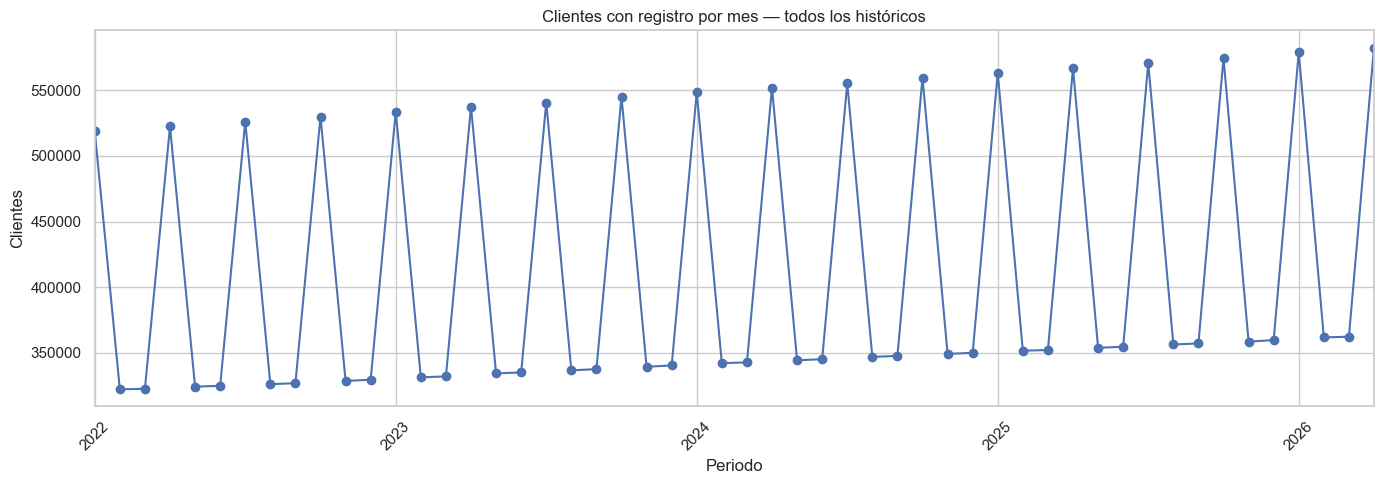

In [60]:
# La cobertura debe calcularse con TODOS los historicos, no con la muestra
# utilizada en las gráficas de distribución.
partes_cobertura = []
for ruta in archivos:
    columnas = [c for c in ["NIU", "periodo", "consumo_kwh_raw"]
                if c in pq.ParquetFile(ruta).schema_arrow.names]
    parte = pd.read_parquet(ruta, columns=columnas, engine="pyarrow")
    parte["periodo"] = pd.to_datetime(parte["periodo"], errors="coerce")
    parte = parte.dropna(subset=["periodo"])
    resumen_archivo = (parte.groupby("periodo")
        .agg(clientes=("NIU", "nunique"), filas=("NIU", "size"),
             consumo_kwh=("consumo_kwh_raw", "sum")))
    partes_cobertura.append(resumen_archivo)
    del parte, resumen_archivo
    gc.collect()

cobertura = pd.concat(partes_cobertura).groupby(level=0).sum().sort_index()
cobertura["clientes_vs_mes_anterior_pct"] = cobertura["clientes"].pct_change().mul(100).round(2)
print(f"Meses incluidos en la cobertura: {len(cobertura)}")
print(f"Periodo: {cobertura.index.min():%Y-%m} a {cobertura.index.max():%Y-%m}")
display(cobertura)
fig, ax = plt.subplots(figsize=(14, 5))
cobertura["clientes"].plot(ax=ax, marker="o")
ax.set_title("Clientes con registro por mes — todos los históricos")
ax.set_xlabel("Periodo")
ax.set_ylabel("Clientes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Esta parte sí usa todos los históricos, no la muestra. Hay 52 meses seguidos, de enero de 2022 a abril de 2026, sin meses saltados. Lo que cambia es la cantidad de clientes por mes: cada tres meses hay un mes "alto" seguido de dos meses "bajos". Los meses altos van de 518.834 clientes en 2022-01 hasta 582.699 en 2026-04, y los bajos de 322.129 a 362.259 en el mismo periodo — ambos van creciendo con el tiempo, solo que el patrón trimestral se mantiene. Ese patrón coincide con clientes rurales que se leen cada tres meses, y es la razón principal para reconstruir el consumo mes a mes antes de modelar.


## 5. Distribuciones del consumo

El consumo suele ser asimétrico. Se muestran escala normal y escala logarítmica para observar clientes pequeños y grandes.

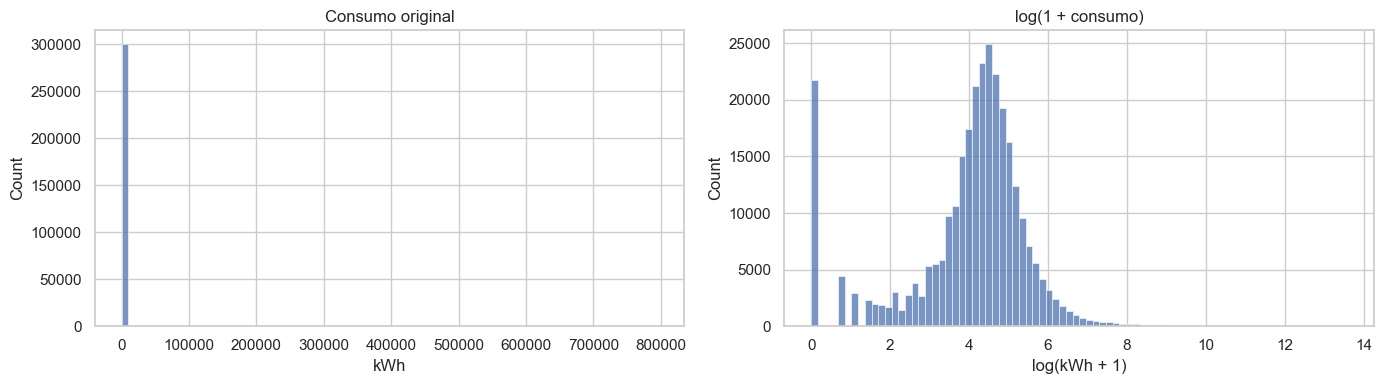

,consumo_kwh_raw
count,300000.000000
mean,169.649873
std,3185.067035
min,0.000000
1%,0.000000
5%,0.000000
25%,33.000000
50%,73.000000
75%,129.000000
95%,362.000000


In [61]:
consumo = pd.to_numeric(df["consumo_kwh_raw"], errors="coerce")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(consumo.clip(lower=0), bins=80, ax=axes[0])
axes[0].set_title("Consumo original")
axes[0].set_xlabel("kWh")
sns.histplot(np.log1p(consumo.clip(lower=0)), bins=80, ax=axes[1])
axes[1].set_title("log(1 + consumo)")
axes[1].set_xlabel("log(kWh + 1)")
plt.tight_layout()
plt.show()
display(consumo.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99,.999]).to_frame("consumo_kwh_raw"))

La mitad de los registros consume 73 kWh o menos (la mediana).Un grupo muy pequeño de valores muy altos —el 0,1% de los registros, por encima de 9.120 kWh— corresponde a clientes grandes (comerciales o industriales), y el consumo más alto de todos fue 795.129 kWh. El promedio (169,65 kWh) es mucho más alto que la mediana precisamente por esos pocos clientes grandes, que "jalan" el promedio hacia arriba. Por eso conviene usar la mediana y marcar los valores altos con una bandera, en vez de borrarlos: son datos reales de clientes grandes, no errores.


## 6. Relaciones principales

Estas comparaciones ayudan a decidir qué variables deben llegar al preprocesamiento y cuáles son solo descriptivas.

In [62]:
for columna in ["clase_servicio", "ciclo", "tipo_lectura", "tipo_medidor", "estrato", "lectura_aprox_trimestral"]:
    if columna in df.columns:
        resumen = (df.groupby(columna, dropna=False)["consumo_kwh_raw"]
            .agg(clientes="nunique", filas="size", mediana="median", promedio="mean")
            .sort_values("clientes", ascending=False).head(30))
        print(f"\n--- {columna} ---")
        display(resumen)



--- clase_servicio ---


,clientes,filas,mediana,promedio
clase_servicio,,,,
CR,2201,23504,81.0,354.643295
RS,1377,246437,72.0,98.335692
<NA>,1075,24000,75.0,176.809000
OF,875,2657,126.0,506.438841
ID,853,1261,605.0,2936.982554
AC,449,1500,40.0,249.086000
AP,183,194,9460.0,29155.912371
RI,116,140,715.0,2119.200000
AA,110,145,180.0,975.820690



--- ciclo ---


,clientes,filas,mediana,promedio
ciclo,,,,
0.0,1441,61569,70.0,123.528367
1.0,1199,47032,69.0,128.775281
9.0,1152,25573,68.0,142.408321
7.0,1089,15962,150.0,258.329219
12.0,1027,23721,75.0,148.527128
2.0,1010,34297,72.0,127.197860
NaN,930,12000,104.0,178.327083
4.0,823,18557,63.0,106.913833
19.0,802,7992,95.0,162.260886



--- tipo_lectura ---


...

,clientes,filas,mediana,promedio
tipo_medidor,,,,
1,2854,274525,73.0,161.217594
2,1227,25142,73.0,244.111646
6,110,333,0.0,1499.240240



--- estrato ---


,clientes,filas,mediana,promedio
estrato,,,,
2.0,2510,163541,74.0,203.403140
3.0,1563,58212,73.0,130.649248
4.0,1191,21333,68.0,163.550087
NaN,930,12000,104.0,178.327083
1.0,806,38015,68.0,97.977246
5.0,460,6807,71.0,94.850448
6.0,83,92,196.5,278.956522



--- lectura_aprox_trimestral ---


,clientes,filas,mediana,promedio
lectura_aprox_trimestral,,,,
False,2825,236278,71.0,171.137093
True,1475,51722,90.0,160.842717
NaN,930,12000,104.0,178.327083


Estas tablas muestran que el consumo cambia bastante según la clase de servicio, el ciclo de facturación, el tipo de lectura o medidor y el estrato. Eso justifica conservar esas columnas para el análisis de negocio y para el glosario. Pero ojo: que dos variables se muevan juntas no significa que una cause la otra, y estos resultados solo vienen de la muestra, no de todo el histórico.


## 6b. Perfil de consumo de alumbrado público y autogeneradores

In [63]:
if {"ciclo", "clase_servicio"}.issubset(df.columns):
    grupo = np.select(
        [
            (df["ciclo"] == 15) & (df["clase_servicio"].astype(str).str.upper() == "AP"),
            df["ciclo"] == 50,
        ],
        ["Alumbrado público (ciclo 15 + AP)", "Autogeneradores (ciclo 50)"],
        default="Resto de clientes",
    )
    perfil_excluidos = (
        df.assign(grupo=grupo)
        .groupby("grupo")["consumo_kwh_raw"]
        .agg(clientes="count", mediana="median", promedio="mean",
             cv=lambda s: s.std() / s.mean() if s.mean() else np.nan)
    )
    display(perfil_excluidos)

,clientes,mediana,promedio,cv
grupo,,,,
Alumbrado público (ciclo 15 + AP),39,5732.0,6996.717949,0.804168
Autogeneradores (ciclo 50),75,71.0,646.720000,2.362573
Resto de clientes,299886,73.0,168.642704,18.880102



El alumbrado público (39 clientes en la muestra) consume mucho (mediana 5.732 kWh) pero de forma muy estable — su `cv` (una medida de qué tan disperso es el consumo dentro del grupo) es 0,80, un valor bajo. Tiene sentido: su consumo no se mide, se calcula con una fórmula fija. Los autogeneradores (75 clientes) consumen poco en la mediana (71 kWh, parecido a un cliente normal), pero su promedio es más alto (646,72 kWh) y su `cv` (2,36) es mayor que el de un cliente típico. El resto de clientes (299.886) tiene el `cv` más alto de los tres grupos (18,88), porque ahí se mezclan clientes pequeños residenciales con clientes industriales enormes. En otras palabras: no se excluyen el alumbrado público y los autogeneradores porque sean los más "raros" en las cifras, sino por una razón de negocio: uno no se mide con medidor y el otro no refleja consumo real de la red.


## 7. Lecturas largas y clientes rurales

,filas,clientes,mediana,promedio
lectura_aprox_trimestral,,,,
False,236278,2825,71.0,171.137093
True,51722,1475,90.0,160.842717
NaN,12000,930,104.0,178.327083


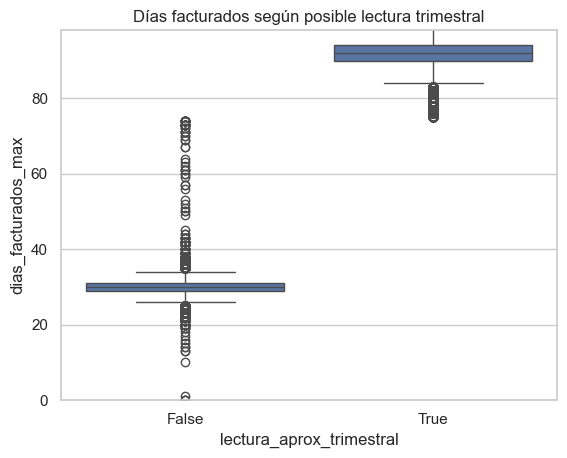

In [64]:
if "lectura_aprox_trimestral" in df.columns:
    tabla = (df.groupby("lectura_aprox_trimestral", dropna=False)["consumo_kwh_raw"]
        .agg(filas="size", clientes="nunique", mediana="median", promedio="mean"))
    display(tabla)
    # La columna tiene nulos (ver sección 3): seaborn no puede ordenar categorías
    # mezclando None con True/False. Se excluyen los nulos solo para el boxplot
    # y se castea a bool "puro" (no boolean nullable).
    datos_boxplot = df.dropna(subset=["lectura_aprox_trimestral"]).assign(
        lectura_aprox_trimestral=lambda x: x["lectura_aprox_trimestral"].astype(bool)
    )
    sns.boxplot(data=datos_boxplot, x="lectura_aprox_trimestral", y="dias_facturados_max")
    plt.ylim(0, df["dias_facturados_max"].quantile(.99) if "dias_facturados_max" in df else 120)
    plt.title("Días facturados según posible lectura trimestral")
    plt.show()

### Interpretación de las lecturas largas

51.722 filas (poco más del 17% de la muestra) están marcadas como lectura trimestral, frente a 236.278 que no lo son (a las 12.000 restantes les falta este dato). Aunque es una minoría, ese grupo trimestral tiene un consumo típico más alto (mediana 90 kWh) que el resto (71 kWh), lo que confirma que se comportan distinto. Esta variable sola no dice con certeza qué cliente es rural, pero sí es evidencia suficiente para justificar por qué el notebook de reconstrucción reparte esas lecturas largas entre los meses que cubren, en vez de dejarlas como si fueran un solo mes de consumo.


## 7b. Periodicidad trimestral por ciclo — evidencia para clasificar ciclos rurales

In [65]:
if {"ciclo", "lectura_aprox_trimestral"}.issubset(df.columns):
    periodicidad_ciclo = (
        df.groupby("ciclo", dropna=False)
        .agg(
            clientes=("NIU", "nunique"),
            filas=("NIU", "size"),
            pct_lecturas_trimestrales=("lectura_aprox_trimestral", "mean"),
        )
        .assign(pct_lecturas_trimestrales=lambda x: (x["pct_lecturas_trimestrales"] * 100).round(2))
        .sort_values("pct_lecturas_trimestrales", ascending=False)
    )
    display(periodicidad_ciclo)

    UMBRAL_RURAL_EDA = 50  # % de lecturas trimestrales para marcar el ciclo como rural
    ciclos_rurales_eda = periodicidad_ciclo.loc[
        periodicidad_ciclo["pct_lecturas_trimestrales"] >= UMBRAL_RURAL_EDA
    ].index.tolist()
    print(f"Ciclos >= {UMBRAL_RURAL_EDA}% de lecturas trimestrales: {ciclos_rurales_eda}")

,clientes,filas,pct_lecturas_trimestrales
ciclo,,,
38.0,55,97,100.0
12.0,10488,23721,99.99
11.0,3130,5088,99.67
22.0,2980,4203,99.67
10.0,3173,4811,99.67
23.0,1782,2649,99.66
21.0,948,1467,99.45
13.0,1193,1832,99.34
19.0,5668,7992,99.14


Ciclos >= 50% de lecturas trimestrales: [38.0, 12.0, 11.0, 22.0, 10.0, 23.0, 21.0, 13.0, 19.0]



Usando 50% como punto de corte (si la mitad o más de las lecturas de un ciclo son trimestrales, ese ciclo se considera rural), esta muestra identifica los mismos ciclos que ya usa el preprocesamiento: 38, 12, 11, 22, 10, 23, 21, 13 y 19. También queda claro que el ciclo 15 (alumbrado público, con solo 7,5% de lecturas trimestrales) y el ciclo 50 (autogeneradores, con 0%) no calificarían como rurales de todas formas, aunque ya se excluyen antes por otra razón (sección 6b).


## 8. Comportamiento por cliente

Los modelos trabajan con historia por cliente. Esta sección calcula cantidad de meses, mediana, variabilidad y porcentaje de ceros.

,count,mean,min,1%,25%,50%,75%,99%,max,std
meses_observados,176390.0,1.700777,1.0,1.0,1.0,1.0,2.0,6.0,6.0,1.182896
consumo_mediana,176390.0,177.249683,0.0,0.0,36.0,75.0,131.0,1220.11,657490.0,3136.522525
consumo_promedio,176390.0,177.558482,0.0,0.0,36.0,75.0,131.0,1214.154,657490.0,3135.742769
consumo_std,74956.0,52.574503,0.0,0.0,6.363961,17.214335,38.431758,410.194918,562241.107818,2087.553421
pct_ceros,176390.0,7.350587,0.0,0.0,0.0,0.0,0.0,100.0,100.0,24.548863
periodo_min,176390,2023-11-13 05:35:04.323374,2022-01-01 00:00:00,2022-01-01 00:00:00,2022-08-01 00:00:00,2023-10-01 00:00:00,2025-02-01 00:00:00,2026-03-01 00:00:00,2026-03-01 00:00:00,NaN
periodo_max,176390,2024-12-27 13:13:44.577356,2022-01-01 00:00:00,2022-08-01 00:00:00,2024-02-01 00:00:00,2025-05-01 00:00:00,2026-01-01 00:00:00,2026-03-01 00:00:00,2026-03-01 00:00:00,NaN
cv,72587.0,0.419606,0.0,0.0,0.113286,0.256556,0.575617,1.561362,2.44949,0.426734


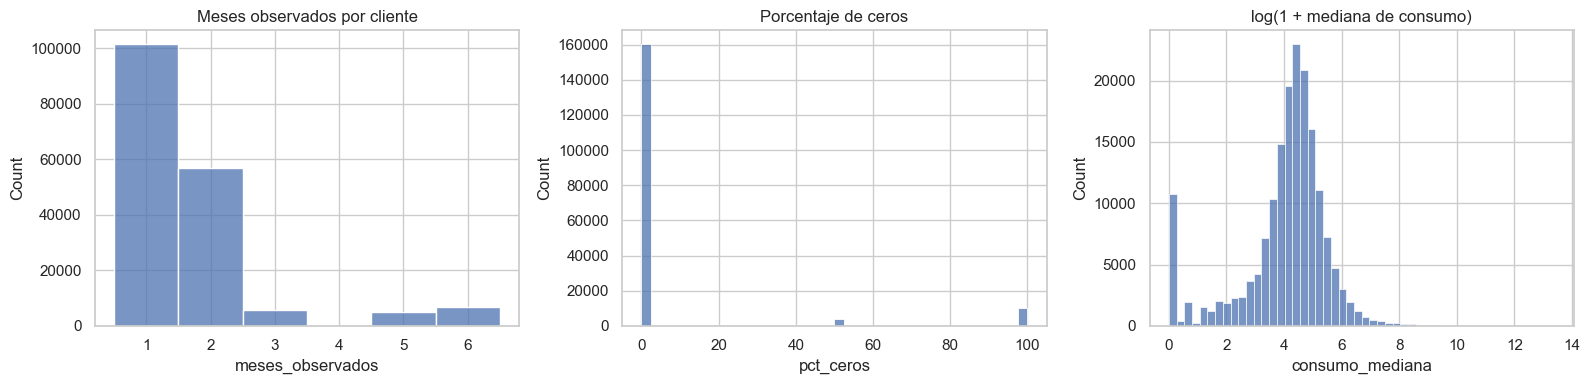

In [70]:
cliente = (df.groupby("NIU")
    .agg(meses_observados=("periodo", "nunique"),
         consumo_mediana=("consumo_kwh_raw", "median"),
         consumo_promedio=("consumo_kwh_raw", "mean"),
         consumo_std=("consumo_kwh_raw", "std"),
         pct_ceros=("consumo_kwh_raw", lambda s: (pd.to_numeric(s, errors="coerce")==0).mean()*100),
         periodo_min=("periodo", "min"),
         periodo_max=("periodo", "max")))
cliente["cv"] = cliente["consumo_std"] / cliente["consumo_promedio"].replace(0, np.nan)
display(cliente.describe(percentiles=[.01,.25,.5,.75,.99]).T)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(cliente["meses_observados"], discrete=True, ax=axes[0])
axes[0].set_title("Meses observados por cliente")
sns.histplot(cliente["pct_ceros"], bins=40, ax=axes[1])
axes[1].set_title("Porcentaje de ceros")
sns.histplot(np.log1p(cliente["consumo_mediana"].clip(lower=0)), bins=50, ax=axes[2])
axes[2].set_title("log(1 + mediana de consumo)")
plt.tight_layout()
plt.show()


En promedio, cada uno de los 176.390 clientes de la muestra aparece en solo 1,70 meses (la mitad aparece en 1 solo mes, y el máximo es 6). Esto no significa que los clientes tengan poca historia real: es que 300.000 filas repartidas entre tantos clientes dejan pocas filas por cliente. El porcentaje de ceros (7,35% en promedio) y la variabilidad del consumo sí sirven como referencia general, pero para segmentar clientes de verdad hay que usar todo su historial, no esta muestra.


## 9. Duplicados por cliente y periodo

La unidad esperada del histórico es `NIU + periodo`. Los duplicados deben investigarse antes de construir la serie mensual.

In [74]:
claves = [c for c in ["NIU", "periodo"] if c in df.columns]
if len(claves) == 2:
    duplicados = df.duplicated(subset=claves, keep=False)
    reporte_duplicados = pd.DataFrame({
        "filas_muestra": [len(df)],
        "filas_duplicadas": [int(duplicados.sum())],
        "porcentaje_duplicado": [round(duplicados.mean() * 100, 3)],
        "grupos_duplicados": [int(df.loc[duplicados, claves].drop_duplicates().shape[0])],
    })
    display(reporte_duplicados)
    if duplicados.any():
        display(df.loc[duplicados].sort_values(claves).head(30))

,filas_muestra,filas_duplicadas,porcentaje_duplicado,grupos_duplicados
0,300000,0,0.0,0


## 10. Continuidad temporal por cliente

Se revisa cuántos meses faltan dentro del intervalo entre el primer y el último registro del cliente. Los huecos pueden afectar la reconstrucción y las ventanas del modelo.

In [71]:
if len(cliente):
    cliente["meses_esperados"] = ((cliente["periodo_max"].dt.year - cliente["periodo_min"].dt.year) * 12 + cliente["periodo_max"].dt.month - cliente["periodo_min"].dt.month + 1)
    cliente["meses_faltantes_intervalo"] = (cliente["meses_esperados"] - cliente["meses_observados"]).clip(lower=0)
    continuidad = cliente["meses_faltantes_intervalo"].describe(percentiles=[.5,.9,.99]).to_frame("meses_faltantes_intervalo")
    display(continuidad)


,meses_faltantes_intervalo
count,176390.000000
mean,12.774057
std,16.733271
min,0.000000
50%,0.000000
90%,43.000000
99%,47.000000
max,47.000000


La mitad de los clientes no tiene ningún mes faltante dentro de su rango de fechas, pero en el 10% con más huecos llegan a faltar hasta 43 meses, y en el 1% más extremo hasta 47. Esto no es un problema real de los datos: como cada cliente aparece en promedio solo 1,70 meses en esta muestra, cualquier rango de fechas amplio se cuenta casi entero como "faltante", aunque el cliente sí tenga esos meses en el histórico completo. Por eso esta métrica no debe usarse para decidir cuántos meses de historia se necesitan para pronosticar; ese cálculo hay que hacerlo sobre el histórico completo de cada cliente.


## 11. Relaciones numéricas

Las correlaciones son exploratorias. No prueban causalidad y no reemplazan la validación temporal.

,consumo_kwh_raw,consumo_promedio_semestral_kwh,tarifa_aplicada_kwh,dias_facturados_max,dias_facturados_mediana,ciclo,tipo_lectura,tipo_factura,tipo_medidor,estrato
consumo_kwh_raw,1.00,0.92,0.02,-0.00,-0.00,0.05,0.01,0.00,0.01,-0.00
consumo_promedio_semestral_kwh,0.92,1.00,0.02,-0.01,-0.01,0.04,0.01,0.00,0.01,0.00
tarifa_aplicada_kwh,0.02,0.02,1.00,-0.23,-0.23,-0.25,0.02,-0.01,0.04,0.73
dias_facturados_max,-0.00,-0.01,-0.23,1.00,1.00,0.78,0.06,0.01,0.00,-0.24
dias_facturados_mediana,-0.00,-0.01,-0.23,1.00,1.00,0.78,0.06,0.01,0.00,-0.24
ciclo,0.05,0.04,-0.25,0.78,0.78,1.00,0.07,0.02,0.03,-0.33
tipo_lectura,0.01,0.01,0.02,0.06,0.06,0.07,1.00,0.00,0.31,-0.01
tipo_factura,0.00,0.00,-0.01,0.01,0.01,0.02,0.00,1.00,-0.00,-0.00
tipo_medidor,0.01,0.01,0.04,0.00,0.00,0.03,0.31,-0.00,1.00,0.04
estrato,-0.00,0.00,0.73,-0.24,-0.24,-0.33,-0.01,-0.00,0.04,1.00


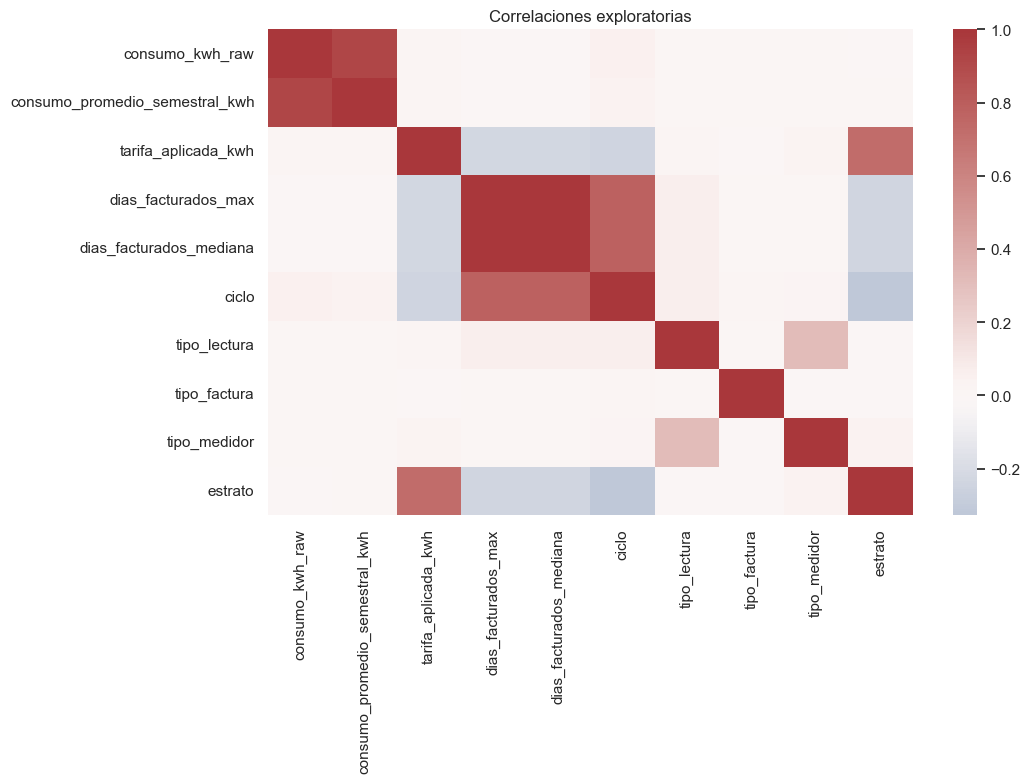

In [72]:
numericas = df.select_dtypes(include=np.number)
if numericas.shape[1] >= 2:
    corr = numericas.corr(numeric_only=True)
    display(corr.round(2))
    fig, ax = plt.subplots(figsize=(11, 8))
    sns.heatmap(corr, cmap="vlag", center=0, annot=False, ax=ax)
    ax.set_title("Correlaciones exploratorias")
    plt.tight_layout()
    plt.show()


Recordatorio: que dos variables tengan una correlación alta no significa que una cause la otra. `consumo_kwh_raw` y `consumo_promedio_semestral_kwh` correlacionan en 0,92 simplemente porque ambas miden lo mismo (consumo). `tarifa_aplicada_kwh` y `estrato` correlacionan en 0,73, algo esperado porque la tarifa depende del estrato. `dias_facturados_max` y `ciclo` correlacionan en 0,78: algunos ciclos tienden a tener facturas de más días, lo cual coincide con los ciclos rurales de lectura trimestral que ya se identificaron en la sección 7b. Ninguna columna fue constante en esta muestra, así que no salió ninguna correlación vacía (`NaN`).


## 12. Valores cero, negativos y extremos

Los ceros pueden ser reales, pero también pueden indicar falta de lectura. Los valores negativos y extremos requieren revisión técnica.

,filas,nulos_pct,ceros_pct,negativos_pct,p001,mediana,p999,mayores_p999_pct
0,300000,0.0,7.257,0.0,0.0,73.0,9120.0,0.1


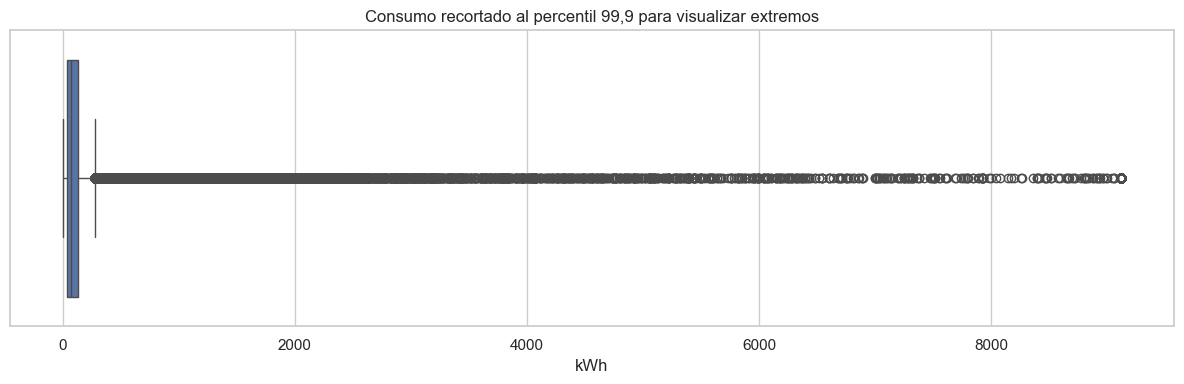

In [75]:
consumo = pd.to_numeric(df["consumo_kwh_raw"], errors="coerce")
q999 = consumo.quantile(0.999)
reporte_consumo = pd.DataFrame({
    "filas": [len(df)],
    "nulos_pct": [round(consumo.isna().mean()*100, 3)],
    "ceros_pct": [round((consumo == 0).mean()*100, 3)],
    "negativos_pct": [round((consumo < 0).mean()*100, 3)],
    "p001": [consumo.quantile(.001)],
    "mediana": [consumo.median()],
    "p999": [q999],
    "mayores_p999_pct": [round((consumo > q999).mean()*100, 3)],
})
display(reporte_consumo)
fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(x=consumo.clip(lower=0, upper=q999), ax=ax)
ax.set_title("Consumo recortado al percentil 99,9 para visualizar extremos")
ax.set_xlabel("kWh")
plt.tight_layout()
plt.show()

## Conclusiones y decisiones

1. **¿Hay meses faltantes?** No faltan meses del calendario: hay 52 meses seguidos, de 2022-01 a 2026-04 (sección 4). Lo que sí cambia es cuántos clientes aparecen cada mes, con un patrón de "un mes alto, dos meses bajos" típico de la lectura rural.
2. **¿Qué porcentaje de valores nulos existe?** `clase_servicio` 8,0%; `lectura_aprox_trimestral`, `estrato`, `ciclo`, `dias_facturados_max` y `dias_facturados_mediana`, 4,0% cada una; el resto de columnas, 0% (sección 3).
3. **¿Hay duplicados por `NIU + periodo`?** No, cero duplicados en la muestra de 300.000 filas (sección 9).
4. **¿Qué variables tienen valores extremos?** El consumo (`consumo_kwh_raw`): el 0,1% más alto supera los 9.120 kWh y el máximo llega a 795.129 kWh. 
5. **¿Qué evidencia justifica la reconstrucción rural?** Tres cosas: el patrón trimestral en la cobertura mensual (sección 4), que el 17,2% de las filas están marcadas como lectura trimestral (sección 7), y que 9 ciclos concretos tienen 50% o más de lecturas trimestrales (sección 7b).
6. **¿Qué columnas pasan al dataset de modelado y cuáles quedan solo para auditoría?** Pasan al modelado: `consumo_kwh_mensual`, `es_rural`, `estado_mes` y las banderas de calidad (`consumo_es_cero`, `consumo_es_negativo`, `consumo_extremo_p999`). Quedan solo para auditoría: `origen_consumo`, `metodos_usados`, `dias_asignados` y `consumo_imputado`. El detalle de cada decisión está en la siguiente seccion.

Estas conclusiones son la base para `Preprocesamiento_serie_tiempo_para_modelado.ipynb`, pero este notebook no modifica el dataset.


## Justificación de las decisiones aplicadas en reconstrucción y preprocesamiento

Esta sección conecta lo que se observó en el EDA con lo que realmente se programó en los notebooks siguientes. Para cada decisión se explica: qué se vio en los datos, qué problema resolvía y qué se implementó.

### Decisión 1: repartir las lecturas largas mes a mes

**Qué se vio:** la cantidad de clientes por mes sube y baja cada tres meses (sección 4), y el 17,2% de las filas de la muestra están marcadas como lectura trimestral (sección 7).

**Por qué es un problema:** si se deja el dato tal cual, un cliente al que le leen el medidor cada tres meses parece que "no consumió" en los dos meses intermedios, cuando en realidad sí consumió, solo que no se lo leyeron ese mes.

**Qué se hizo:** en `Reconstruccion_serie_tiempo_consumo_rural.ipynb` se reparte ese consumo entre los meses que cubre la lectura, usando las fechas reales cuando existen, o un reparto por días facturados cuando no.

**Qué queda guardado:** la columna `consumo_kwh_mensual` (el consumo ya repartido), y además `origen_consumo`, `metodos_usados`, `dias_asignados` y `consumo_imputado`, para poder revisar después cómo se calculó cada valor.

### Decisión 2: separar clientes urbanos de rurales

**Qué se vio:** no todos los ciclos de facturación se comportan igual — algunos tienen lecturas casi siempre mensuales y otros casi siempre trimestrales (sección 7b).

**Por qué es un problema:** si se usa una sola regla para todos los clientes, un cliente rural que normalmente no tiene lectura ese mes se vería igual que un error o una caída real.

**Qué se hizo:** en el preprocesamiento se crea la columna `es_rural` a partir de una lista fija de ciclos (`CICLOS_RURALES`), usando el mismo corte de 50% que se calcula en la sección 7b de este EDA.

### Decisión 3: distinguir meses ya cerrados de meses todavía incompletos

**Qué se vio:** el número de clientes por mes cambia mucho, y un mes con pocos registros no siempre significa que se perdieron clientes — puede ser que todavía no ha llegado toda la información, sobre todo de zonas rurales.

**Por qué es un problema:** si se usa el último mes tal cual para entrenar o para evaluar el modelo, ese mes va a parecer una caída falsa solo porque está incompleto.

**Qué se hizo:** se crea la columna `estado_mes`, que marca cada mes como `CONSOLIDADO` (ya cerrado) o `PROVISIONAL` (todavía puede cambiar), y solo se descartan los meses provisionales del final.

### Decisión 4: no borrar los ceros, pero sí marcarlos

**Qué se vio:** el 7,257% de los registros de consumo son cero. (Seccion 12)

**Por qué es un problema:** un cero puede ser un cliente que de verdad no consumió, o puede ser que no se tomó la lectura ese mes. Borrarlo perdería información real; tratarlo como consumo normal también sería un error.

**Qué se hizo:** se deja el valor cero tal como está y se agrega la columna `consumo_es_cero`, para que el modelo pueda distinguir después entre "cliente sin consumo", "cliente intermitente" y "no hay lectura".

### Decisión 5: marcar los valores negativos y extremos, sin borrarlos

**Qué se vio:** el 0,1% de los registros con mayor consumo supera los 9.120 kWh, y el máximo llega a 795.129 kWh — muy por encima de la mediana (73 kWh), señal de que hay clientes grandes mezclados con el resto (sección 12).

**Por qué es un problema:** si se borran automáticamente los valores altos, se puede estar borrando clientes comerciales o industriales que sí consumen así de verdad.

**Qué se hizo:** se agregan las columnas `consumo_es_negativo` y `consumo_extremo_p999`, se conserva el valor original, y se deja que cada modelo (o el negocio) decida cómo tratarlos.

### Decisión 6: exigir un mínimo de historia para poder pronosticar

**Qué se vio:** con pocos meses de historia no se puede calcular una tendencia ni una estacionalidad confiable — algo que también se vio en las secciones 13 y 14 de este EDA, donde una muestra pequeña por cliente distorsiona esas métricas.

**Por qué es un problema:** intentar pronosticar el consumo de un cliente con muy poca historia da resultados poco confiables.

**Qué se hizo:** se calcula cuántos meses válidos tiene cada cliente, y a los que no alcanzan el mínimo se les asigna el perfil `P4_INSUFICIENTE`, para que el modelo los trate distinto.

### Decisión 7: separar las variables según su uso

**Qué se vio:** el histórico mezcla variables originales, códigos de lectura, tarifas, fechas y campos que indican de dónde salió cada dato — no todas sirven para lo mismo.

**Qué se hizo:**

- se conserva el histórico original, sin tocar, para poder rastrear cualquier dato hasta su origen;
- se construye la serie mensual reconstruida, que representa el consumo ya repartido por mes;
- se construye la serie de modelado, con las banderas y el estado de cada mes;
- se recuperan los atributos comerciales (ciclo, clase de servicio, etc.) por separado, para listas y reportes de negocio.

### Decisión 8: sacar del modelo el alumbrado público y los autogeneradores

**Qué se vio:** el alumbrado público (ciclo 15 + AP) consume mucho pero de forma muy estable, porque su consumo se calcula con una fórmula y no se mide con medidor. Los autogeneradores (ciclo 50) producen su propia energía, así que consumen menos de la red por diseño (sección 6b).

**Por qué es un problema:** si se dejan estos clientes en el modelo, cualquier cambio en su consumo —que no tiene que ver con un cliente real que sube o baja su uso de la red— se vería como una caída o una desviación, y no lo es.

**Qué se hizo:** se excluyen por completo del universo de modelado, tanto los clientes de alumbrado público (ciclo 15 + clase de servicio "AP") como los autogeneradores (ciclo 50), decisión de negocio tomada el 2026-09-09.

